#### Visualization demo of `pinn_pat_A_recon_example.ckpt`

- Checkpoint is generated by `../run/run_reconstruct.py`
- The PINN model is optimized with constraints of sensor data, wave equation and initial condition ($\partial p / \partial t|_{t=0}=0$)

------

In [3]:
import torch
torch.set_grad_enabled(False)
import sys
from matplotlib import pyplot as plt
import json
from pprint import pprint
sys.path.append("..")


from models.pinn_for_pat import PINNForPAT
from models.arg import Arg
device = torch.device("cpu")

In [2]:
ckpt_filepath = "../ckpt/reconstruct/pinn_pat_A_recon_example.ckpt"
state_dict = torch.load(ckpt_filepath, map_location=torch.device('cpu'))

arg_dict = json.loads(bytes(state_dict['arg'].numpy()).decode('utf-8'))
pprint(arg_dict)

arg = Arg.from_dict(arg_dict)
arg.load_filepath = ckpt_filepath
pinn_pat = PINNForPAT(arg, device=device)

{'activation': 'Sin',
 'bc_batch_size': 75,
 'dpdt0_weight': 1e-06,
 'fit_type': 'Inverse',
 'in_channels': 3,
 'l_layers': 9,
 'load_filepath': '../ckpt/gaussian/pinn_pat_gs_init.ckpt',
 'lr_end': 1e-05,
 'lr_start': 0.0002,
 'medium': 'A: Homogeneous and unlossy',
 'n_hidden': 180,
 'n_t': 700,
 'num_iteration': 700000,
 'out_channels': 1,
 'p0_batch_size': None,
 'p0_filepath': None,
 'pde_batch_size': 15000,
 'pde_weight': 1e-07,
 'save_filepath': '../ckpt/reconstruct/pinn_pat_A_0917_2249_3.ckpt',
 'sensor_filepath': '../sensor/vessel/A_300_700_40dB.pts',
 't0_batch_size': 2500,
 't_max': 1.05,
 't_min': 0.0}
Load: ../ckpt/reconstruct/pinn_pat_A_recon_example.ckpt <All keys matched successfully>
 [PINNForPAT]  {'medium': 'A: Homogeneous and unlossy', 'fit_type': 'Inverse', 'in_channels': 3, 'out_channels': 1, 'n_hidden': 180, 'l_layers': 9, 'activation': 'Sin', 't_min': 0.0, 't_max': 1.05, 'n_t': 700, 'pde_batch_size': 15000, 't0_batch_size': 2500, 'bc_batch_size': 75, 'p0_batch_si

### Reconstruction result (initial pressure)

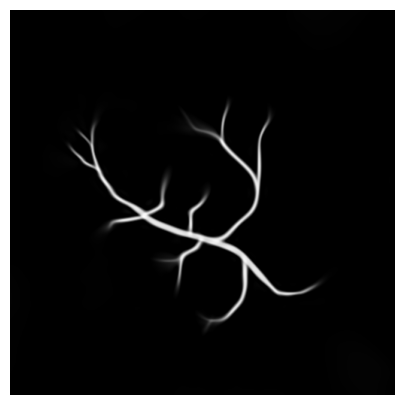

In [4]:
H = 512
X_axis = torch.linspace(0, 1, 2 * H + 1)[1::2]
x, y = torch.meshgrid([X_axis] * 2, indexing="ij")
xyt = torch.zeros([H, H, 3])
xyt[:, :, 0] = x
xyt[:, :, 1] = y
p0 = pinn_pat.p(xyt)

fig, ax = plt.subplots(dpi=100, figsize=(5, 5))
ax.axis(False)
ax.imshow(p0, vmin=0, cmap="Grays_r")

### Evolution of loss and PSNR of optimization

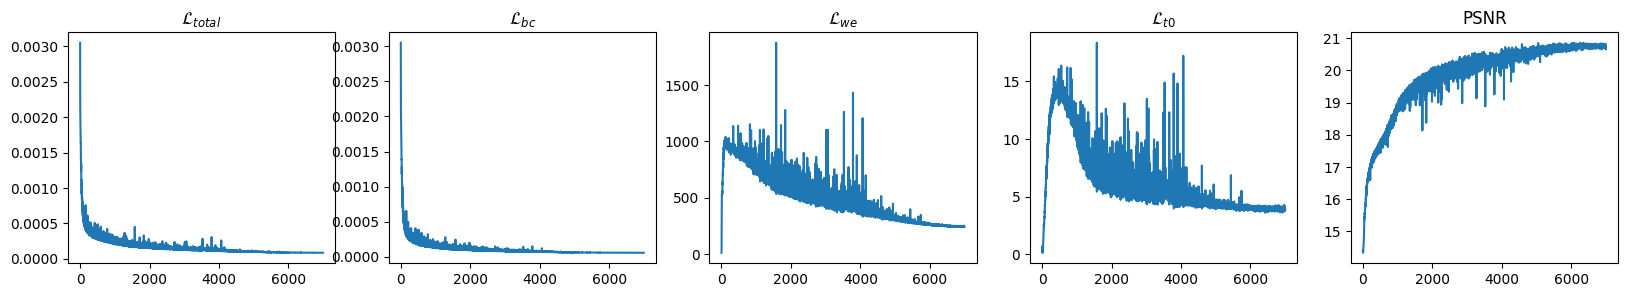

In [12]:
loss_list = state_dict["loss_list"]
psnr_list = state_dict["psnr_list"]
fig, axes = plt.subplots(dpi=100, figsize=(20, 3), ncols=5)
titles = [r"$\mathcal{L}_{total}$", r"$\mathcal{L}_{bc}$", r"$\mathcal{L}_{we}$", r"$\mathcal{L}_{t0}$", "PSNR"]
for iax, curve in enumerate(list(loss_list.T[:4]) + [psnr_list]):
    axes[iax].plot(curve)
    axes[iax].set_title(titles[iax])

